In [1]:
!pip install -q sentence-transformers google-genai neo4j faiss-cpu pandas networkx matplotlib

In [2]:
import faiss, numpy as np
from sentence_transformers import SentenceTransformer
from neo4j import GraphDatabase
from google import genai
import pandas as pd

/Users/josephgeorge225/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
URI='bolt://localhost:7687'
USERNAME='neo4j'
PASSWORD='admin1234'
driver=GraphDatabase.driver(URI,auth=(USERNAME,PASSWORD))

In [ ]:
import os
client=genai.Client(api_key=os.getenv("GEMINI_API_KEY"))


In [5]:
def load_nodes(tx):
    q='''
    MATCH (n)
    OPTIONAL MATCH (n)-[r]->(m)
    RETURN n.id as id, n.label as name,
            n.type as node_type,
           type(r) as edge_type,
           collect(type(r)+': '+coalesce(m.label,'')) as relationships
    '''
    return list(tx.run(q))
with driver.session() as s:
    nodes=s.execute_read(load_nodes)

In [7]:
node_docs=[]
for r in nodes:
    txt=f"""Type: {r['node_type']}
Name: {r['name']}
Relationships:
{' '.join(r['relationships'])}"""
    node_type = r['node_type']
    node_name = r['name']
    node_docs.append({'id':r['id'],'text':txt, 'node_type': node_type, 'node_name':node_name})

df = pd.DataFrame(node_docs)
df.to_csv("data.csv", index=False)

print("Saved to data.csv")

Saved to data.csv


In [38]:
def load_edges(tx):
    q = """
    MATCH (a)-[r]->(b)
    RETURN
        id(a) AS source,
        id(b) AS target,
        type(r) AS relation,
        a.label AS source_name,
        b.label AS target_name,
        a.type as source_type,
        b.type as target_type
    """
    return list(tx.run(q))
with driver.session() as s:
    edges=s.execute_read(load_edges)

edge_docs=[{'source':e['source'],'target':e['target'],'source_name':e['source_name'],'target_name':e['target_name'],'source_type':e['source_type'],'target_type':e['target_type'],
'text':f"{e['source_name']} {e['relation'].lower().replace('_',' ')} {e['target_name']}",'edge_type': e['relation']}
for e in edges]

df1 = pd.DataFrame(edge_docs)
df1.to_csv("data_edges.csv", index=False)

print("Saved to data.csv")

Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. id is deprecated. It is replaced by elementId or consider using an application-generated id.', position=<SummaryInputPosition line=4, column=9, offset=43>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 43, 'line': 4, 'column': 9}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    MATCH (a)-[r]->(b)\n    RETURN\n        id(a) AS source,\n        id(b) AS target,\n        type(r) AS relation,\n        a.label AS source_name,\n        b.label AS target_name,\n        a.type as source_type,\n        b.type as target_type\n    '
Received notification from DBMS server: <GqlStatusObject gql_

Saved to data.csv


In [42]:
def embed(texts):
    response = client.models.embed_content(
        model="gemini-embedding-001",
        contents=texts
    )
    return np.array(
        [emb.values for emb in response.embeddings],
        dtype=np.float32
    )

In [53]:
model=SentenceTransformer("all-MiniLM-L6-v2",device="cpu")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 14500.01it/s]


In [43]:
node_emb=embed([d['text'] for d in node_docs])
edge_emb=embed([d['text'] for d in edge_docs])

In [44]:
dim=node_emb.shape[1]
node_index=faiss.IndexFlatIP(dim)
edge_index=faiss.IndexFlatIP(dim)
node_index.add(node_emb)
edge_index.add(edge_emb)

In [49]:
query='What is the latest news related to Manchester United'
#query='What is the salary of Sarah'

qv=embed([query]).astype('float32')
_,nids=node_index.search(qv,5)
_,eids=edge_index.search(qv,5)

print('Node hits')
for i in nids[0]:
    print(node_docs[i])

print('\nRelationship hits')
for i in eids[0]:
    print(edge_docs[i])

Node hits
{'id': 15, 'text': 'Type: Entity\nName: Manchester United\nRelationships:\nATTEMPTING_TO_SIGN: Mbeumo TO_TOUR: United States COMPETES_IN: Premier League WON_AGAINST: Manchester City'}
{'id': 12, 'text': 'Type: Episodic\nName: ESPN Transfer News 1\nRelationships:\n'}
{'id': 36, 'text': 'Type: Entity\nName: Manchester City\nRelationships:\n'}
{'id': 43, 'text': 'Type: Entity\nName: Mark Ogden\nRelationships:\nREPORTS_ON: Marcus Rashford'}
{'id': 32, 'text': 'Type: Entity\nName: Old Trafford\nRelationships:\n'}

Relationship hits
{'source': 15, 'target': 35, 'text': 'Manchester United relates to Premier League'}
{'source': 12, 'target': 15, 'text': 'ESPN Transfer News 1 mentions Manchester United'}
{'source': 12, 'target': 32, 'text': 'ESPN Transfer News 1 mentions Old Trafford'}
{'source': 15, 'target': 25, 'text': 'Manchester United relates to United States'}
{'source': 15, 'target': 36, 'text': 'Manchester United relates to Manchester City'}


In [50]:
def expand(tx,node_id):
    q='''
    MATCH (n) WHERE id(n)=$id
    OPTIONAL MATCH (n)-[r]-(m)
    RETURN n.name as source,m.name as target, r.name as relation,r.fact as summary
    '''
    return list(tx.run(q,id=node_id))

top=node_docs[nids[0][0]]['id']
with driver.session() as s:
    context=s.execute_read(expand,top)
context

Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. id is deprecated. It is replaced by elementId or consider using an application-generated id.', position=<SummaryInputPosition line=2, column=21, offset=21>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 21, 'line': 2, 'column': 21}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    MATCH (n) WHERE id(n)=$id\n    OPTIONAL MATCH (n)-[r]-(m)\n    RETURN n.name as source,m.name as target, r.name as relation,r.fact as summary\n    '


[<Record source='Manchester United' target='Transfer Update 2' relation=None summary=None>,
 <Record source='Manchester United' target='ESPN Transfer News 1' relation=None summary=None>,
 <Record source='Manchester United' target='Mbeumo' relation='ATTEMPTING_TO_SIGN' summary='Manchester United is close to signing Mbeumo before their U.S. tour.'>,
 <Record source='Manchester United' target='United States' relation='TO_TOUR' summary='Manchester United is embarking on a pre-season tour in the United States.'>,
 <Record source='Manchester United' target='Premier League' relation='COMPETES_IN' summary='Manchester United won a match 2-1 in the Premier League against Manchester City.'>,
 <Record source='Manchester United' target='Manchester City' relation='WON_AGAINST' summary='Manchester United secured a 2-1 Premier League win at Manchester City.'>,
 <Record source='Manchester United' target='Marcus Rashford' relation='TRANSFERRING_FROM' summary='Marcus Rashford is completing a season-long 

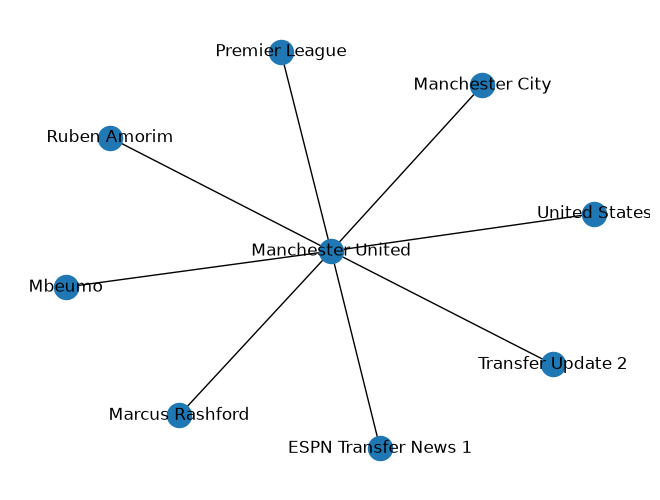

In [52]:
import networkx as nx
import matplotlib.pyplot as plt
G=nx.Graph()
for r in context:
    if r['target']:
        G.add_edge(r['source'],r['target'],label=r['relation'])
nx.draw(G,with_labels=True)
plt.show()